In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import time
import math
from numba import cuda, int32

def load_and_display_image(file_path):
    img = mpimg.imread(file_path)
    if img.dtype in [np.float32, np.float64]:
        img = (img * 255).astype(np.uint8)
    else:
        img = img.astype(np.uint8)
    return img

image_path = "/kaggle/input/datasets/phmquangdnga/picturee/image2.jpg"
img = load_and_display_image(image_path)

h = img.shape[0]
w = img.shape[1]
channels = img.shape[2] if len(img.shape) == 3 else 1

print(f"Image shape: {img.shape}")

Image shape: (4536, 8064, 3)


CPU time: 40.36997413635254 seconds


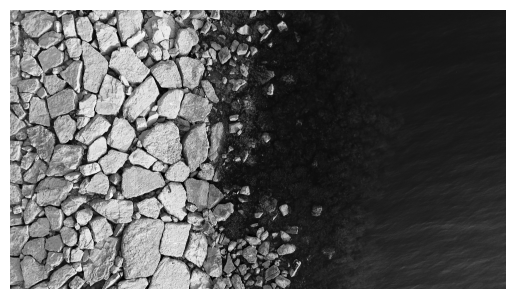

In [8]:
def grayscale_cpu(src):
    gray = np.zeros_like(src)
    for y in range(h):
        for x in range(w):
            g = (
                int(src[y, x, 0]) +
                int(src[y, x, 1]) +
                int(src[y, x, 2])
            ) / 3
            gray[y, x, 0] = g
            gray[y, x, 1] = g
            gray[y, x, 2] = g
    return gray

start_cpu = time.time()
gray_cpu = grayscale_cpu(img)
end_cpu = time.time()

print("CPU time:", end_cpu - start_cpu, "seconds")

plt.imshow(gray_cpu)
plt.axis('off')
plt.show()

In [9]:
@cuda.jit
def grayscale_gpu_2d(src, dst):
    x = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    y = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y

    if x < w and y < h:
        g = np.uint8(
            (int(src[y, x, 0]) +
             int(src[y, x, 1]) +
             int(src[y, x, 2])) / 3
        )
        dst[y, x, 0] = g
        dst[y, x, 1] = g
        dst[y, x, 2] = g

In [12]:
block_sizes = [(8, 8), (16,8), (8,16), (16, 16), (32, 16),(16, 32),(32, 32)]
gpu_times = []

devSrc = cuda.to_device(img)
devDst = cuda.device_array((h, w, channels), dtype=np.uint8)

for blockSize in block_sizes:
    gridSize = (
        math.ceil(w / blockSize[0]),
        math.ceil(h / blockSize[1])
    )

    grayscale_gpu_2d[gridSize, blockSize](devSrc, devDst)
    cuda.synchronize()

    times = []
    for i in range(5):
        start = time.time()
        grayscale_gpu_2d[gridSize, blockSize](devSrc, devDst)
        cuda.synchronize()
        end = time.time()
        
        times.append(end - start)

    average_time = sum(times) / 5
    gpu_times.append(average_time)

    print("Block size:", blockSize)
    print("Times:", times)
    print("Average time:", average_time)

Block size: (8, 8)
Times: [0.009039163589477539, 0.00899815559387207, 0.00899505615234375, 0.009000539779663086, 0.008992433547973633]
Average time: 0.009005069732666016
Block size: (16, 8)
Times: [0.008993864059448242, 0.008966922760009766, 0.00897073745727539, 0.009228706359863281, 0.009000539779663086]
Average time: 0.009032154083251953
Block size: (8, 16)
Times: [0.009005308151245117, 0.009015560150146484, 0.008994579315185547, 0.008997678756713867, 0.009054183959960938]
Average time: 0.00901346206665039
Block size: (16, 16)
Times: [0.00882411003112793, 0.004395961761474609, 0.004311800003051758, 0.004032611846923828, 0.003980159759521484]
Average time: 0.005108928680419922
Block size: (32, 16)
Times: [0.004004240036010742, 0.004004716873168945, 0.003976345062255859, 0.003972291946411133, 0.0039675235748291016]
Average time: 0.003985023498535157
Block size: (16, 32)
Times: [0.004010915756225586, 0.003986358642578125, 0.003979682922363281, 0.003981113433837891, 0.00403904914855957]


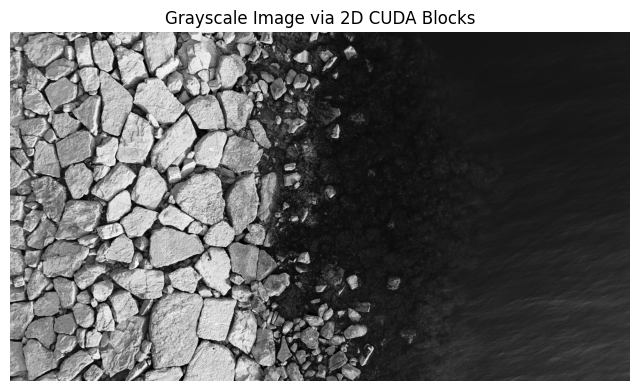

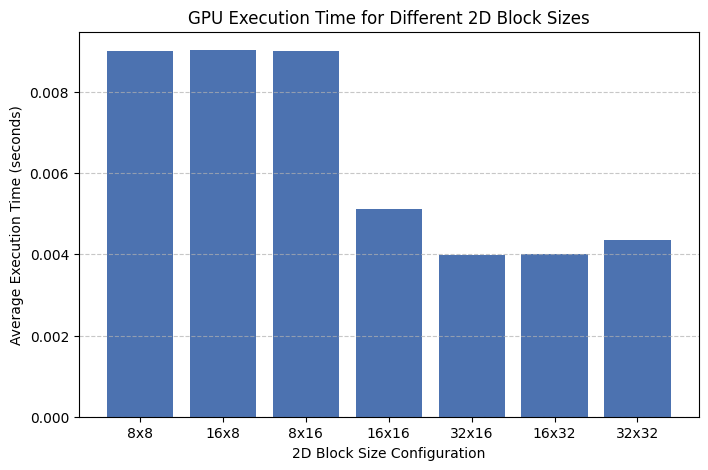

In [13]:
hostDst = devDst.copy_to_host()
plt.figure(figsize=(8, 6))
plt.imshow(hostDst)
plt.axis('off')
plt.title('Grayscale Image via 2D CUDA Blocks')
plt.show()

labels = [f"{x}x{y}" for x, y in block_sizes]
plt.figure(figsize=(8, 5))
plt.bar(labels, gpu_times, color='#4C72B0')
plt.xlabel("2D Block Size Configuration")
plt.ylabel("Average Execution Time (seconds)")
plt.title("GPU Execution Time for Different 2D Block Sizes")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()